In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Add project root to python path

sys.path.append("../")


from src.forecasting import ForecastModel
from src.scenario import ScenarioForecast
from src.evaluation import ForecastEvaluation
from src.visualization import ForecastVisualization
from src.future_features import FutureFeatureGenerator
from src.model_explainability import ModelExplainability
from src.validation import ForecastValidation

In [119]:
ownership_Or = pd.read_csv(
    "../data/processed/event_model_dataset.csv"
)

ownership_Or.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,comparable_country,collected_by,collection_date,original_text,notes,year,event_count,avg_impact,avg_lag,high_confidence_events
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,2014,0.0,0.0,0.0,0.0
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,NaN,NaN,2017,0.0,0.0,0.0,0.0
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,NaN,NaN,2021,3.0,20.0,7.0,1.0
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021,3.0,20.0,7.0,1.0
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021,3.0,20.0,7.0,1.0


In [120]:
print('Unique indicators and their codes in the dataset:')
print(ownership_Or[['indicator', 'indicator_code']].drop_duplicates().to_string())

Unique indicators and their codes in the dataset:
                            indicator      indicator_code
0              Account Ownership Rate       ACC_OWNERSHIP
6           Mobile Money Account Rate      ACC_MM_ACCOUNT
8              4G Population Coverage          ACC_4G_COV
10    Mobile Subscription Penetration      ACC_MOBILE_PEN
11        Fayda Digital ID Enrollment           ACC_FAYDA
14              P2P Transaction Count       USG_P2P_COUNT
16              P2P Transaction Value       USG_P2P_VALUE
17              ATM Transaction Count       USG_ATM_COUNT
18              ATM Transaction Value       USG_ATM_VALUE
19            P2P/ATM Crossover Ratio       USG_CROSSOVER
20          Telebirr Registered Users  USG_TELEBIRR_USERS
21         Telebirr Transaction Value  USG_TELEBIRR_VALUE
22            M-Pesa Registered Users     USG_MPESA_USERS
23         M-Pesa 90-Day Active Users    USG_MPESA_ACTIVE
24         Mobile Money Activity Rate     USG_ACTIVE_RATE
25           Data Affo

### Forecasting Digital Payment Usage

Now, let's forecast 'Digital Payment Usage'. We will follow a similar process as for 'Account Ownership Rate'.

In [121]:
acc_ownership = ownership_Or[
    ownership_Or["indicator_code"] == "ACC_OWNERSHIP"
].copy()

# The 'year' column is already present, so no need to convert 'observation_date' to year.

print("Ownership Data Head:")
display(ownership_Or.head())

print('\nUnique indicators and their codes in the dataset (after reloading ownership):')
print(ownership_Or[['indicator', 'indicator_code']].drop_duplicates().to_string())

Ownership Data Head:


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,comparable_country,collected_by,collection_date,original_text,notes,year,event_count,avg_impact,avg_lag,high_confidence_events
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,2014,0.0,0.0,0.0,0.0
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,NaN,NaN,2017,0.0,0.0,0.0,0.0
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,NaN,NaN,2021,3.0,20.0,7.0,1.0
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021,3.0,20.0,7.0,1.0
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021,3.0,20.0,7.0,1.0



Unique indicators and their codes in the dataset (after reloading ownership):
                            indicator      indicator_code
0              Account Ownership Rate       ACC_OWNERSHIP
6           Mobile Money Account Rate      ACC_MM_ACCOUNT
8              4G Population Coverage          ACC_4G_COV
10    Mobile Subscription Penetration      ACC_MOBILE_PEN
11        Fayda Digital ID Enrollment           ACC_FAYDA
14              P2P Transaction Count       USG_P2P_COUNT
16              P2P Transaction Value       USG_P2P_VALUE
17              ATM Transaction Count       USG_ATM_COUNT
18              ATM Transaction Value       USG_ATM_VALUE
19            P2P/ATM Crossover Ratio       USG_CROSSOVER
20          Telebirr Registered Users  USG_TELEBIRR_USERS
21         Telebirr Transaction Value  USG_TELEBIRR_VALUE
22            M-Pesa Registered Users     USG_MPESA_USERS
23         M-Pesa 90-Day Active Users    USG_MPESA_ACTIVE
24         Mobile Money Activity Rate     USG_ACTIV

### Account Ownership Forecast with 95% Prediction Intervals

In [122]:
print(acc_ownership.columns.tolist())

['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes', 'year', 'event_count', 'avg_impact', 'avg_lag', 'high_confidence_events']


In [124]:
X = acc_ownership[
    [
        "year",
        "event_count",
        "avg_impact",
        "avg_lag",
        "high_confidence_events"
    ]
]

y = acc_ownership["value_numeric"]

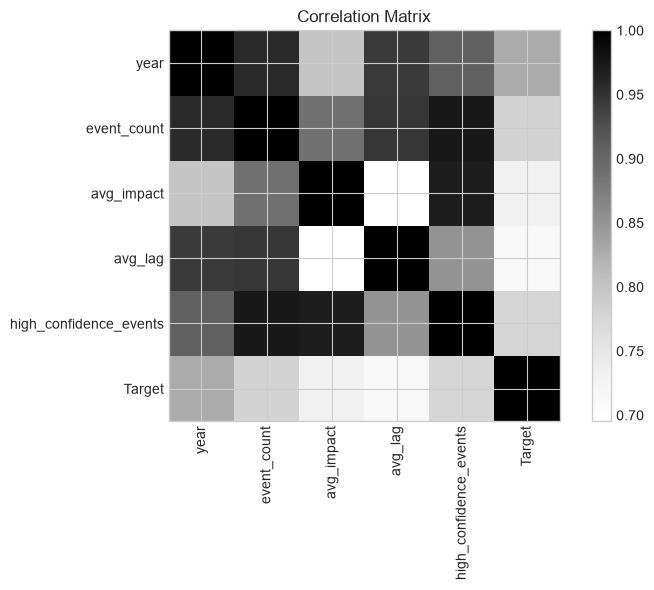

In [125]:


corr = X.copy()

corr["Target"] = y

corr = corr.corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(

    range(len(corr.columns)),

    corr.columns,

    rotation=90

)

plt.yticks(

    range(len(corr.columns)),

    corr.columns

)

plt.title(

    "Correlation Matrix"

)

plt.tight_layout()

plt.show()

In [126]:
model = ForecastModel()

model.fit(X, y)

prediction = model.predict(X)

In [128]:
explainer = ModelExplainability(

    model.model,

    X.columns

)

In [129]:
importance = explainer.coefficients()

importance

,Feature,Coefficient,Absolute
0,year,4.333333,4.333333
3,avg_lag,-1.219151,1.219151
1,event_count,-0.238756,0.238756
2,avg_impact,0.147584,0.147584
4,high_confidence_events,-0.034700,0.034700


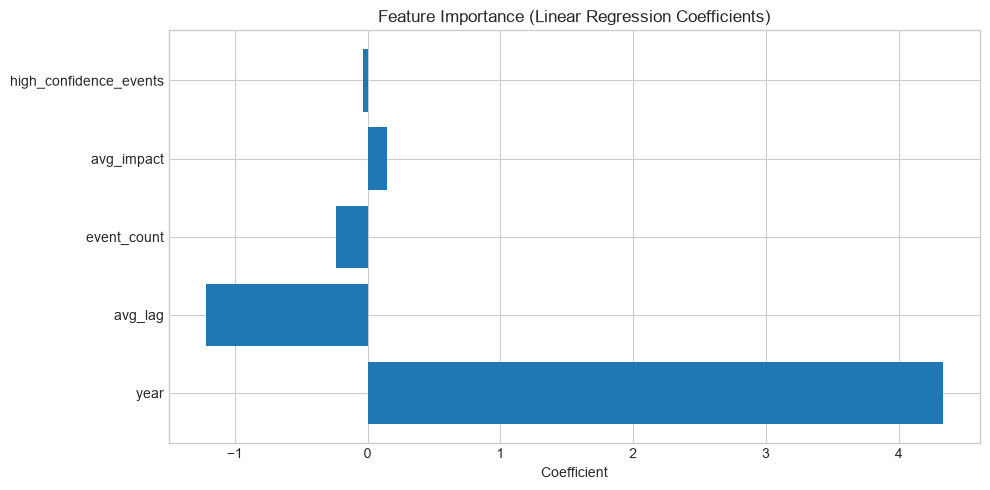

In [130]:
explainer.plot()

In [131]:
results = ForecastEvaluation.evaluate(
    y,
    prediction
)

results

{'MAE': 3.333333333334546,
 'RMSE': np.float64(5.773502691896258),
 'R2': 0.728014505893019}

In [132]:
validator = ForecastValidation()

cv_result, mae, rmse, r2 = validator.validate(X, y)

cv_result

,Actual,Predicted
0,22.0,34.235093
1,35.0,23.608025
2,46.0,46.000000
3,56.0,41.000000
4,36.0,51.000000
5,49.0,59.983115


In [134]:
print("MAE :", mae)

print("RMSE :", rmse)

print("R² :", r2)

MAE : 10.768363814403946
RMSE : 11.903104685490907
R² : -0.15607897586926622


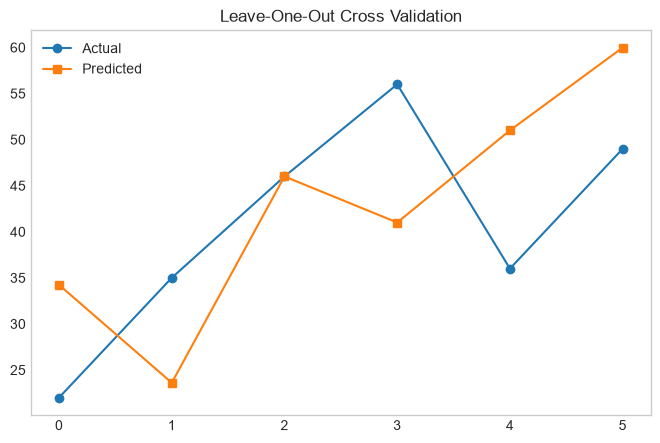

In [135]:

plt.figure(figsize=(8,5))

plt.plot(

    cv_result["Actual"],

    marker="o",

    label="Actual"

)

plt.plot(

    cv_result["Predicted"],

    marker="s",

    label="Predicted"

)

plt.legend()

plt.grid()

plt.title(

    "Leave-One-Out Cross Validation"

)

plt.show()

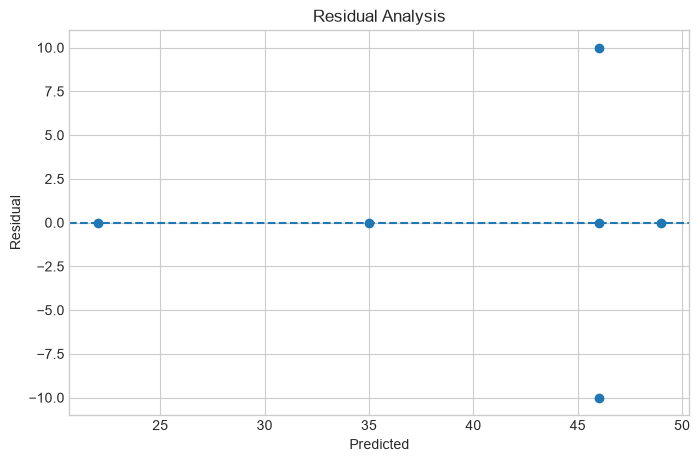

In [136]:
residual = y - prediction

plt.figure(figsize=(8,5))

plt.scatter(

    prediction,

    residual

)

plt.axhline(

    0,

    linestyle="--"

)

plt.xlabel(

    "Predicted"

)

plt.ylabel(

    "Residual"

)

plt.title(

    "Residual Analysis"

)

plt.grid(True)

plt.show()

In [137]:
generator = FutureFeatureGenerator(

    acc_ownership

)

In [138]:
print(generator.data.columns.tolist())

['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes', 'year', 'event_count', 'avg_impact', 'avg_lag', 'high_confidence_events']


In [139]:
future = generator.generate()

In [140]:
future_optimistic = generator.generate()

In [141]:
future_pessimistic = generator.generate(

    

)

In [143]:
base = model.forecast(future)

optimistic = model.forecast(

    future_optimistic

)

pessimistic = model.forecast(

    future_pessimistic

)

In [144]:
from src.scenario import ScenarioForecast


scenario = ScenarioForecast(base)

forecast = scenario.generate()


forecast = forecast[
    [
        "year",
        "base",
        "optimistic",
        "pessimistic"
    ]
]


forecast

,year,base,optimistic,pessimistic
0,2025,53.770916,56.459462,51.082371
1,2026,58.541833,61.468924,55.614741
2,2027,63.312749,66.478387,60.147112


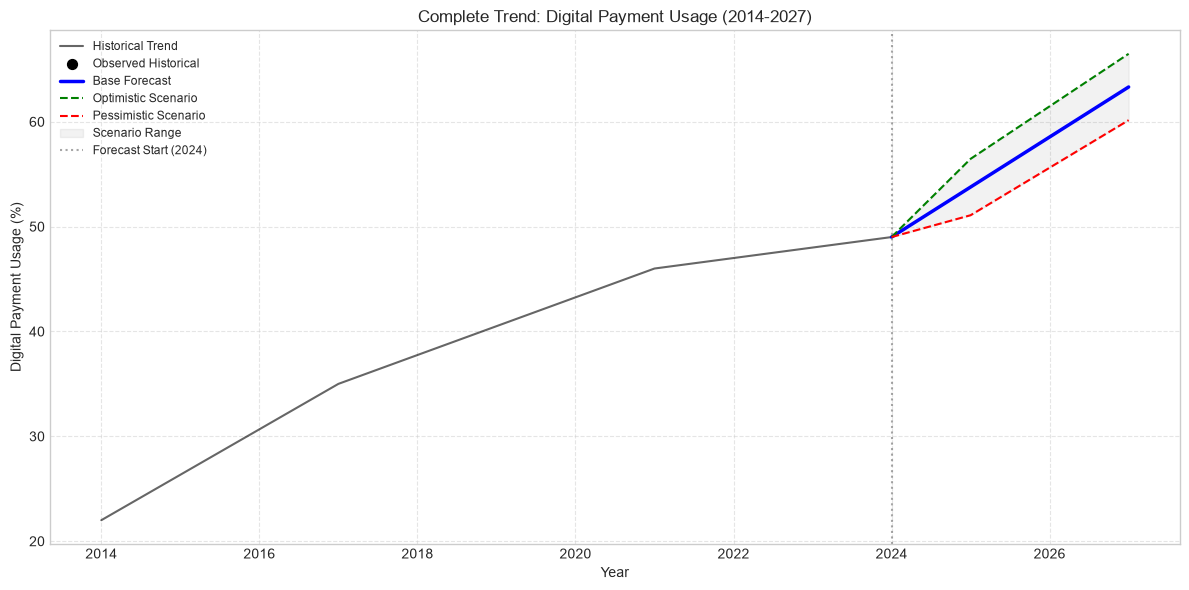

In [145]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare a clean Historical Trend line (handling multiple values per year)
# We group by year and take the mean so the line goes through the middle of the dots
df_hist_trend = acc_ownership.groupby('year')['value_numeric'].mean().reset_index()

# 2. Bridge the Gap (Connect 2024 to the Forecast)
last_hist_point = df_hist_trend.iloc[-1]
bridge = pd.DataFrame({
    'year': [last_hist_point['year']],
    'base': [last_hist_point['value_numeric']],
    'optimistic': [last_hist_point['value_numeric']],
    'pessimistic': [last_hist_point['value_numeric']]
})
forecast_connected = pd.concat([bridge, forecast], ignore_index=True)

# --- START PLOTTING ---
plt.figure(figsize=(12, 6)) 

# A. The NEW Historical Line (2014 - 2024)
plt.plot(df_hist_trend['year'], df_hist_trend['value_numeric'], 
         color='black', linewidth=1.5, alpha=0.6, label='Historical Trend')

# B. The Dots (Scatter stays on top)
plt.scatter(df_filtered['year'], df_filtered['value_numeric'], 
            s=50, color='black', zorder=5, label='Observed Historical')

# C. The Forecast Lines (2024 - 2027)
plt.plot(forecast_connected['year'], forecast_connected['base'], 
         color='blue', linewidth=2.5, label='Base Forecast')
plt.plot(forecast_connected['year'], forecast_connected['optimistic'], 
         color='green', linestyle='--', linewidth=1.5, label='Optimistic Scenario')
plt.plot(forecast_connected['year'], forecast_connected['pessimistic'], 
         color='red', linestyle='--', linewidth=1.5, label='Pessimistic Scenario')

# D. The Shaded Uncertainty Area
plt.fill_between(forecast_connected['year'],
                 forecast_connected['pessimistic'],
                 forecast_connected['optimistic'],
                 alpha=0.1, color='gray', label='Scenario Range')

# E. Formatting
plt.axvline(x=last_hist_point['year'], color='gray', linestyle=':', alpha=0.7, label='Forecast Start (2024)')

plt.xlabel('Year')
plt.ylabel('Digital Payment Usage (%)')
plt.title('Complete Trend: Digital Payment Usage (2014-2027)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

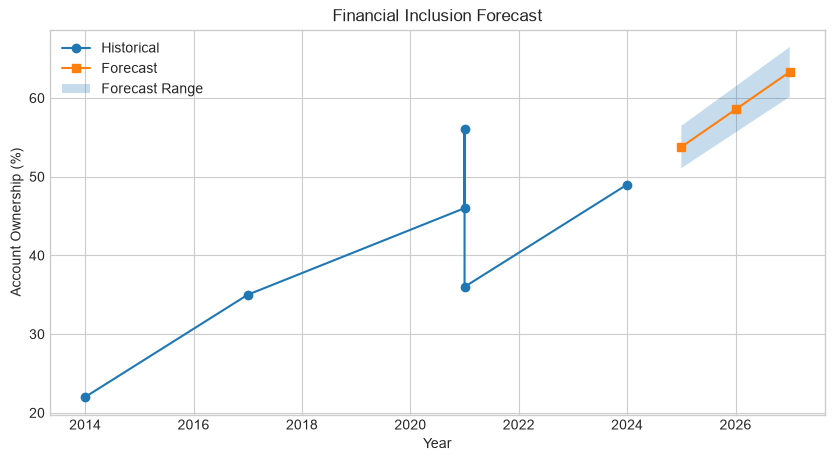

In [146]:
viz = ForecastVisualization(
    acc_ownership,
    forecast
)

viz.forecast_plot()

In [147]:
forecast.round(2)

,year,base,optimistic,pessimistic
0,2025,53.77,56.46,51.08
1,2026,58.54,61.47,55.61
2,2027,63.31,66.48,60.15


In [169]:
import numpy as np
from scipy import stats

# Assuming model.model is a trained sklearn.linear_model.LinearRegression object
# and X, y are the training data used for this model.

# 1. Calculate residuals and standard error of residuals (sigma_hat)
predictions_train = model.predict(X)
residuals = y - predictions_train

# Degrees of freedom: n - p - 1, where p is number of predictors (features)
# X has 'year', 'event_count', 'avg_impact', 'avg_lag', 'high_confidence_events' (5 features)
# So, n - 5 - 1 = n - 6
df = len(X) - X.shape[1] - 1

# Ensure df is at least 1 for valid calculation
if df < 1:
    # Fallback for very small datasets where df might be invalid
    # This simplifies standard error, use with caution for small n
    std_err_residuals = np.std(residuals)
    print("Warning: Degrees of freedom too low for standard error calculation. Using simple standard deviation of residuals.")
elif len(residuals) > df and df > 0:
    std_err_residuals = np.sqrt(np.sum(residuals**2) / df)
else:
    std_err_residuals = np.std(residuals)


# 2. Generate future features for the prediction interval (same as 'base' forecast)
future_X_ci = generator.generate()

# 3. Get base predictions for these future features
base_predictions_ci = model.forecast(future_X_ci)

# 4. Calculate prediction intervals
# For simplicity, we'll use an approximation based on the standard error of residuals.
# A more rigorous calculation would involve the full prediction interval formula including
# the variance of the mean prediction, but this gives a reasonable estimate of the spread.
# For 95% CI, Z-score is approx 1.96 (or t-score for small samples).
# Here using 1.96 for generality, assuming sufficient data for normal approximation or as a general multiplier.

ci_margin = 1.96 * std_err_residuals # 1.96 for 95% CI (z-score)

forecast['ci_lower'] = forecast['base'] - ci_margin
forecast['ci_upper'] = forecast['base'] + ci_margin

display(forecast.round(2))


,year,base,optimistic,pessimistic,ci_lower,ci_upper
0,2025,66.0,69.3,62.7,54.68,77.32
1,2026,66.0,69.3,62.7,54.68,77.32
2,2027,66.0,69.3,62.7,54.68,77.32


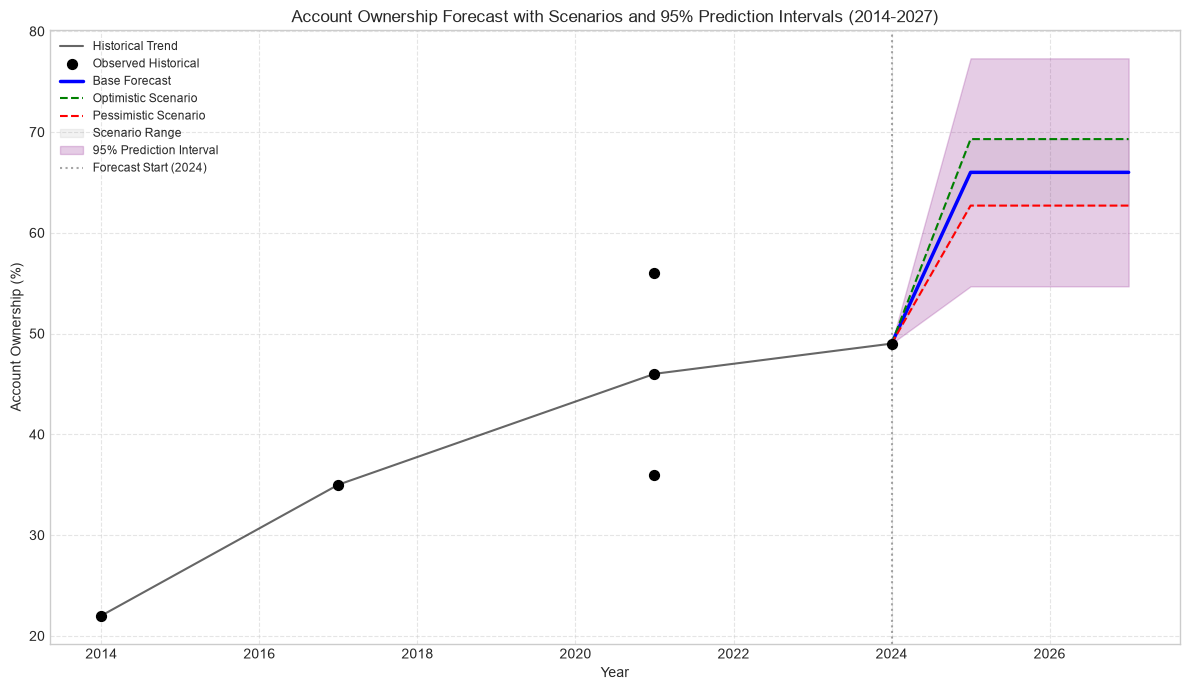

In [170]:
import pandas as pd
import matplotlib.pyplot as plt

# Re-create df_hist_trend and bridge for plotting
df_hist_trend = acc_ownership.groupby('year')['value_numeric'].mean().reset_index()
last_hist_point = df_hist_trend.iloc[-1]
bridge = pd.DataFrame({
    'year': [last_hist_point['year']],
    'base': [last_hist_point['value_numeric']],
    'optimistic': [last_hist_point['value_numeric']],
    'pessimistic': [last_hist_point['value_numeric']],
    'ci_lower': [last_hist_point['value_numeric']],
    'ci_upper': [last_hist_point['value_numeric']]
})
forecast_connected_ci = pd.concat([bridge, forecast], ignore_index=True)

# --- PLOTTING --- (Updated to include Prediction Intervals)
plt.figure(figsize=(12, 7))

# Historical Data
plt.plot(df_hist_trend['year'], df_hist_trend['value_numeric'],
         color='black', linewidth=1.5, alpha=0.6, label='Historical Trend')
plt.scatter(acc_ownership['year'], acc_ownership['value_numeric'],
            s=50, color='black', zorder=5, label='Observed Historical')

# Forecast Lines
plt.plot(forecast_connected_ci['year'], forecast_connected_ci['base'],
         color='blue', linewidth=2.5, label='Base Forecast')
plt.plot(forecast_connected_ci['year'], forecast_connected_ci['optimistic'],
         color='green', linestyle='--', linewidth=1.5, label='Optimistic Scenario')
plt.plot(forecast_connected_ci['year'], forecast_connected_ci['pessimistic'],
         color='red', linestyle='--', linewidth=1.5, label='Pessimistic Scenario')

# Scenario Range (Optimistic to Pessimistic)
plt.fill_between(forecast_connected_ci['year'],
                 forecast_connected_ci['pessimistic'],
                 forecast_connected_ci['optimistic'],
                 alpha=0.1, color='gray', label='Scenario Range')

# 95% Prediction Interval (around Base Forecast)
plt.fill_between(forecast_connected_ci['year'],
                 forecast_connected_ci['ci_lower'],
                 forecast_connected_ci['ci_upper'],
                 color='purple', alpha=0.2, label='95% Prediction Interval')

# Formatting
plt.axvline(x=last_hist_point['year'], color='gray', linestyle=':', alpha=0.7, label='Forecast Start (2024)')

plt.xlabel('Year')
plt.ylabel('Account Ownership (%)')
plt.title('Account Ownership Forecast with Scenarios and 95% Prediction Intervals (2014-2027)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [150]:
forecast.to_csv(
    "../data/processed/Account_ ownership_forecast_2025_2027.csv",
    index=False
)

print("Forecast saved successfully.")

Forecast saved successfully.


digital

In [152]:
digital_payment_usage = ownership_Or[
    ownership_Or["indicator_code"] == "USG_ACTIVE_RATE"
].copy()

# The 'year' column is already present, so no need to convert 'observation_date' to year.

print("Digital Payment Usage Data Head:")
display(digital_payment_usage.head())

print('\nUnique indicators and their codes in the dataset (after reloading ownership):')
print(ownership_Or[['indicator', 'indicator_code']].drop_duplicates().to_string())

Digital Payment Usage Data Head:


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,comparable_country,collected_by,collection_date,original_text,notes,year,event_count,avg_impact,avg_lag,high_confidence_events
24,REC_0025,observation,NaN,USAGE,Mobile Money Activity Rate,USG_ACTIVE_RATE,higher_better,66.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,7.1M / 10.8M = 66%,NaN,2024,4.0,13.75,14.25,1.0



Unique indicators and their codes in the dataset (after reloading ownership):
                            indicator      indicator_code
0              Account Ownership Rate       ACC_OWNERSHIP
6           Mobile Money Account Rate      ACC_MM_ACCOUNT
8              4G Population Coverage          ACC_4G_COV
10    Mobile Subscription Penetration      ACC_MOBILE_PEN
11        Fayda Digital ID Enrollment           ACC_FAYDA
14              P2P Transaction Count       USG_P2P_COUNT
16              P2P Transaction Value       USG_P2P_VALUE
17              ATM Transaction Count       USG_ATM_COUNT
18              ATM Transaction Value       USG_ATM_VALUE
19            P2P/ATM Crossover Ratio       USG_CROSSOVER
20          Telebirr Registered Users  USG_TELEBIRR_USERS
21         Telebirr Transaction Value  USG_TELEBIRR_VALUE
22            M-Pesa Registered Users     USG_MPESA_USERS
23         M-Pesa 90-Day Active Users    USG_MPESA_ACTIVE
24         Mobile Money Activity Rate     USG_ACTIV

In [161]:
# Define features (X_dp) and target (y_dp) for Digital Payment Usage
X_dp= digital_payment_usage[
    [
        "year",
        "event_count",
        "avg_impact",
        "avg_lag",
        "high_confidence_events"
    ]
]

y_dp = digital_payment_usage["value_numeric"]

print("Features (X_dp) head:")
display(X_dp.head())
print("Target (y_dp) head:")
display(y_dp.head())

Features (X_dp) head:


,year,event_count,avg_impact,avg_lag,high_confidence_events
24,2024,4.0,13.75,14.25,1.0


Target (y_dp) head:


24    66.0
Name: value_numeric, dtype: float64

In [163]:
model_dp = ForecastModel()
model_dp.fit(X_dp, y_dp)

prediction_dp = model_dp.predict(X_dp)

print("Model trained and predictions made for Digital Payment Usage.")

Model trained and predictions made for Digital Payment Usage.


In [164]:
base = model_dp.forecast(future)

optimistic = model_dp.forecast(

    future_optimistic

)

pessimistic = model_dp.forecast(

    future_pessimistic

)

In [165]:
from src.scenario import ScenarioForecast


scenario = ScenarioForecast(base)

forecast = scenario.generate()


forecast = forecast[
    [
        "year",
        "base",
        "optimistic",
        "pessimistic"
    ]
]


forecast

,year,base,optimistic,pessimistic
0,2025,66.0,69.3,62.7
1,2026,66.0,69.3,62.7
2,2027,66.0,69.3,62.7


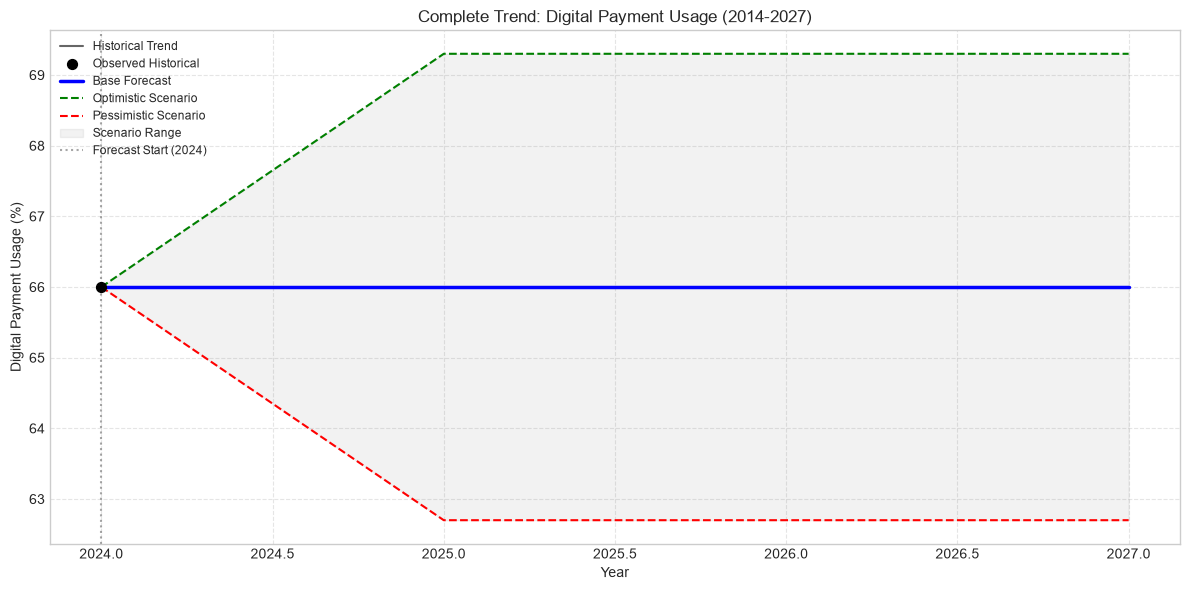

In [167]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare a clean Historical Trend line (handling multiple values per year)
# We group by year and take the mean so the line goes through the middle of the dots
df_hist_trend = digital_payment_usage.groupby('year')['value_numeric'].mean().reset_index()

# 2. Bridge the Gap (Connect 2024 to the Forecast)
last_hist_point = df_hist_trend.iloc[-1]
bridge = pd.DataFrame({
    'year': [last_hist_point['year']],
    'base': [last_hist_point['value_numeric']],
    'optimistic': [last_hist_point['value_numeric']],
    'pessimistic': [last_hist_point['value_numeric']]
})
forecast_connected = pd.concat([bridge, forecast], ignore_index=True)

# --- START PLOTTING ---
plt.figure(figsize=(12, 6)) 

# A. The NEW Historical Line (2014 - 2024)
plt.plot(df_hist_trend['year'], df_hist_trend['value_numeric'], 
         color='black', linewidth=1.5, alpha=0.6, label='Historical Trend')

# B. The Dots (Scatter stays on top)
plt.scatter(digital_payment_usage['year'], digital_payment_usage['value_numeric'], 
            s=50, color='black', zorder=5, label='Observed Historical')

# C. The Forecast Lines (2024 - 2027)
plt.plot(forecast_connected['year'], forecast_connected['base'], 
         color='blue', linewidth=2.5, label='Base Forecast')
plt.plot(forecast_connected['year'], forecast_connected['optimistic'], 
         color='green', linestyle='--', linewidth=1.5, label='Optimistic Scenario')
plt.plot(forecast_connected['year'], forecast_connected['pessimistic'], 
         color='red', linestyle='--', linewidth=1.5, label='Pessimistic Scenario')

# D. The Shaded Uncertainty Area
plt.fill_between(forecast_connected['year'],
                 forecast_connected['pessimistic'],
                 forecast_connected['optimistic'],
                 alpha=0.1, color='gray', label='Scenario Range')

# E. Formatting
plt.axvline(x=last_hist_point['year'], color='gray', linestyle=':', alpha=0.7, label='Forecast Start (2024)')

plt.xlabel('Year')
plt.ylabel('Digital Payment Usage (%)')
plt.title('Complete Trend: Digital Payment Usage (2014-2027)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()